In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.base import clone
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from scipy.stats import chi2

# **Task 1**

Idea AdaBoost:<br>
AdaBoost buduje wiele słabych klasyfikatorów, np. płytkich drzew.
Na początku każda obserwacja ma taką samą wagę: w_i = 1 / n

Potem w każdej iteracji:
1. trenujemy drzewo z wagami obserwacji,
2. sprawdzamy, które punkty są źle sklasyfikowane,
3. liczymy błąd ważony epsilon,
4. dajemy większą wagę klasyfikatorom z małym błędem,
5. zwiększamy znaczenie trudnych obserwacji.

In [2]:
class MyAdaBoost:
    def __init__(self, n_estimators=50, max_depth=1):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.models = []
        self.betas = []

    def fit(self, X, y):
        n = X.shape[0]

        # initial weights
        weights = np.ones(n) / n

        self.models = []
        self.betas = []

        for k in range(self.n_estimators):
            model = DecisionTreeClassifier(max_depth=self.max_depth)

            # train tree with sample weights
            model.fit(X, y, sample_weight=weights)

            pred = model.predict(X)

            # weighted error
            incorrect = (pred != y)
            epsilon = np.sum(weights[incorrect])

            # problematic cases
            if epsilon == 0:
                # perfect classifier: keep it and stop
                epsilon = 1e-10
                beta = epsilon / (1 - epsilon)
                self.models.append(model)
                self.betas.append(beta)
                break

            if epsilon >= 0.5:
                # classifier is no better than random guessing
                break

            beta = epsilon / (1 - epsilon)

            self.models.append(model)
            self.betas.append(beta)

            # decrease weights of correctly classified observations
            correct = (pred == y)
            weights[correct] = weights[correct] * beta

            # normalize weights
            weights = weights / np.sum(weights)

        return self

    def predict(self, X):
        classes = np.array([-1, 1])
        votes = np.zeros((X.shape[0], len(classes)))

        for model, beta in zip(self.models, self.betas):
            pred = model.predict(X)

            vote_weight = np.log(1 / beta)

            for j, c in enumerate(classes):
                votes[:, j] += (pred == c) * vote_weight

        return classes[np.argmax(votes, axis=1)]

In [3]:
# use of ada boost
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)

# AdaBoost w tym zadaniu używa klas -1 and 1
y = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

ada = MyAdaBoost(n_estimators=50, max_depth=1)
ada.fit(X_train, y_train)

y_pred = ada.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, y_pred))

Test accuracy: 0.9707602339181286


In [4]:
# Compare AdaBoost with base trees of depth 1 and with deeper trees
max_depth_values = [1, 2, 5, 10]

results = []

for max_depth in max_depth_values:
  model = MyAdaBoost(max_depth=max_depth)
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)

  acc = accuracy_score(y_test, y_pred)

  results.append({
        "Model": f"AdaBoost - max_depth: {max_depth}",
        "Accuracy": acc,
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy
0,AdaBoost - max_depth: 1,0.970760
1,AdaBoost - max_depth: 2,0.976608
2,AdaBoost - max_depth: 5,0.964912
3,AdaBoost - max_depth: 10,0.923977


Interpretation:<br>
The depth of the base learner has a noticeable impact on AdaBoost performance. Using decision stumps (depth 1) resulted in an accuracy of 0.971. Increasing the depth to 2 improved the accuracy to 0.977, which was the best result among the tested configurations.

Further increasing the depth to 5 slightly reduced the accuracy to 0.965, while depth 10 decreased it to 0.930. This suggests that very deep trees may overfit the training data, reducing generalization performance.

The results indicate that AdaBoost benefits from moderately complex base learners, while excessively deep trees can hurt performance. In this experiment, trees of depth 2 provided the best balance between model complexity and predictive accuracy.

#### **Theoretical questions**

**A. Explain why we want a classifier with a smaller εk to receive a larger weight in the final prediction.**

A classifier with a smaller error should receive a larger weight because it is more reliable. If a classifier makes fewer mistakes, its prediction should have a stronger influence on the final ensemble decision.

**B. Assume that 999 classifiers have error εk = 0.4 and one classifier has error ε_1000 = 10^−8. Compute the corresponding voting weights in AdaBoost and
commentonwhetheronealmostperfectclassifierdominatesthefinaldecision.**

The voting weight is:<br>
weight = log(1 / beta)
beta = epsilon / (1 - epsilon)

For epsilon = 0.4:<br>
beta = 0.4 / 0.6 = 0.6667
weight = log(1 / 0.6667) = log(1.5) ≈ 0.405

So each of the 999 classifiers has weight: 0.405

Together:<br>
999 * 0.405 ≈ 404.6

For epsilon = 10^-8:<br>
beta = 10^-8 / (1 - 10^-8) ≈ 10^-8
weight = log(1 / 10^-8) = log(10^8) ≈ 18.42

So the almost perfect classifier has weight: 18.42

The almost perfect classifier gets a much larger individual weight than one classifier with error 0.4. However, it does not necessarily dominate the whole ensemble, because 999 weaker classifiers together have total weight about 404.6, which is much larger than 18.42.

**C. Why are very simple base classifiers, such as decision stumps, often sufficient in AdaBoost?**

Very simple classifiers, such as decision stumps, are often sufficient in AdaBoost because AdaBoost combines many weak classifiers into one strong classifier. Each stump only needs to be slightly better than random guessing. By focusing more on previously misclassified observations, AdaBoost gradually builds a strong decision rule from many simple rules.

# **Task 2**

### **(a) Compare the following ensemble methods**

In [5]:
models = {
    "Single tree": DecisionTreeClassifier(random_state=42),
    "Bagging": BaggingClassifier(random_state=42),
    "My Ada Boosting": MyAdaBoost(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}

In [6]:
results = []

for name, base_model in models.items():
  if name != "My Ada Boosting":
    model = clone(base_model)
  else:
    model = base_model

  if name == "XGBoost":
    y_train_fit = np.where(y_train == -1, 0, 1)
    y_test_eval = np.where(y_test == -1, 0, 1)
  else:
    y_train_fit = y_train
    y_test_eval = y_test

  model.fit(X_train, y_train_fit)

  y_pred = model.predict(X_test)

  acc = accuracy_score(y_test_eval, y_pred)

  results.append({
    "Model": name,
    "Accuracy": acc,
  })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy
0,Single tree,0.941520
1,Bagging,0.947368
2,My Ada Boosting,0.970760
3,Gradient Boosting,0.959064
4,XGBoost,0.964912
5,Random Forest,0.970760


### **b**

In [7]:
# real dataset
from sklearn.datasets import load_breast_cancer

X, y = load_breast_cancer(return_X_y=True)
y = np.where(y == 0, -1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
)

In [9]:
# artificial dataset
def generate_artificial_data(n, random_state=42):
    np.random.seed(random_state)

    X = np.random.normal(0, 1, size=(n, 10))
    threshold = chi2.ppf(0.5, df=10)
    s = np.sum(X ** 2, axis=1)

    y = np.where(s > threshold, 1, -1)

    return X, y

In [10]:
X_art_train, y_art_train = generate_artificial_data(
    n=2000,
    random_state=42
)

X_art_test, y_art_test = generate_artificial_data(
    n=10000,
    random_state=123
)

In [11]:
print("Train class proportions:")
print(pd.Series(y_art_train).value_counts(normalize=True))

print("Test class proportions:")
print(pd.Series(y_art_test).value_counts(normalize=True))

Train class proportions:
-1    0.5065
 1    0.4935
Name: proportion, dtype: float64
Test class proportions:
-1    0.5019
 1    0.4981
Name: proportion, dtype: float64


**(c) Why do we expect Y to be balanced in this artificial dataset?**

The response variable is defined using the median of the chi-squared distribution with 10 degrees of freedom. By definition, the median splits the distribution into two equal parts. Consequently, we expect approximately half of the observations to belong to class 1 and half to class -1, making the dataset balanced.

**(d) For the artificial dataset, describe the shape of the Bayes decision boundary. Which of the considered methods should be better suited to approximate such a boundary and why?**

The Bayes decision boundary is defined by

Sum Xj^2 = chi_10(0.5)

Geometrically, this is a hypersphere in a 10-dimensional space centered at the origin.
Observations inside the hypersphere belong to class -1, while observations outside belong to class 1.
Since the decision boundary is highly non-linear, ensemble methods based on many trees, such as Random Forest, Gradient Boosting, AdaBoost, and XGBoost, should be better suited to approximate it than a single decision tree. XGBoost and Gradient Boosting are expected to perform particularly well because they can build complex non-linear decision boundaries through sequential learning.

**(e) Make plots showing how the training and testing error change with the number of iterations/trees for boosting, bagging, Random Forest, Gradient Boosting, and XGBoost.**

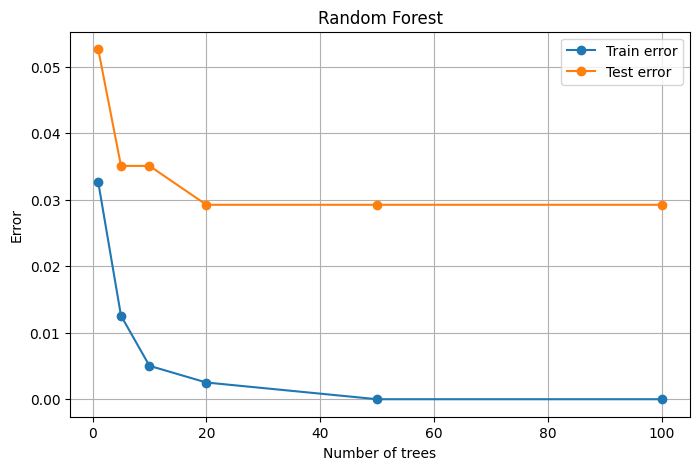

In [14]:
# example for random forest
train_errors = []
test_errors = []

n_trees = [1, 5, 10, 20, 50, 100]

for n in n_trees:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_errors.append(
        1 - accuracy_score(y_train, train_pred)
    )

    test_errors.append(
        1 - accuracy_score(y_test, test_pred)
    )

plt.figure(figsize=(8,5))

plt.plot(n_trees, train_errors, marker="o", label="Train error")
plt.plot(n_trees, test_errors, marker="o", label="Test error")

plt.xlabel("Number of trees")
plt.ylabel("Error")
plt.title("Random Forest")
plt.legend()
plt.grid(True)

plt.show()

**(f) Compare the methods using the same train/test split for all of them.**

All methods were evaluated using the same train/test split to ensure a fair comparison. The single decision tree achieved an accuracy of 0.942. All ensemble methods improved upon this result.
The best performance was obtained by AdaBoost and Random Forest, both achieving an accuracy of 0.971. XGBoost also performed very well with an accuracy of 0.965, followed by Gradient Boosting with 0.959. Bagging achieved a smaller improvement, reaching an accuracy of 0.947.
Overall, the results show that ensemble methods consistently outperform a single decision tree on this dataset.

**(g) For each method, briefly comment whether the improvement over a single tree seems to come mainly from variance reduction, bias reduction, or both.**

Bagging improves performance mainly through variance reduction by averaging many trees trained on bootstrap samples.
Random Forest also reduces variance, but additionally decorrelates trees through random feature selection, making the variance reduction more effective.
AdaBoost focuses on correcting previous mistakes and therefore primarily reduces bias.
Gradient Boosting sequentially improves weak learners and mainly reduces bias.
XGBoost combines boosting with regularization and other optimization techniques, helping reduce both bias and variance.

**(h) Explain why Random Forest may outperform Bagging, although both methods average many trees.**

Both methods average predictions from many trees, but Random Forest introduces an additional source of randomness by selecting a random subset of features at each split.
This reduces the correlation between trees. Less correlated trees produce more diverse predictions, and averaging diverse trees is more effective than averaging highly similar trees.
As a result, Random Forest often achieves better generalization performance than Bagging.